## Instance segmentation model performance ##

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import json
import time
import glob
import random
from pathlib import Path
from dotenv import load_dotenv

from matplotlib import pyplot as plt
from matplotlib.pyplot import cm
from matplotlib import patches

# Appearance of the Notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
np.set_printoptions(linewidth=110)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)

# PyTorch libraries
import torch

# Detectron2 library
import detectron2
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog, DatasetCatalog, build_detection_test_loader
from detectron2.evaluation import COCOEvaluator, inference_on_dataset

# Import this module with autoreload
%load_ext autoreload
%autoreload 2
import computervision as dm
from computervision.imageproc import ImageData
from computervision.fileutils import FileOP
from computervision.inference import get_gpu_info

print(f'Project module version: {dm.__version__}')
print(f'Detectron2 version:     {detectron2.__version__}')

/home/andreas/gitrepos/computervision/.venv/lib/python3.12/site-packages/detectron2/model_zoo/model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Project module version: 0.0.1
Detectron2 version:     0.6


In [2]:
# GPU checks
device, device_str = get_gpu_info()
print()
print(f'Device for model training/inference: {device}')

CUDA available: True
Number of GPUs found:  1
Current device ID: 0
GPU device name:   NVIDIA GeForce RTX 3060 Laptop GPU
PyTorch version:   2.13.0+cu130
CUDA version:      13.0
CUDNN version:     92000
Current device:    cuda:0

Device for model training/inference: cuda:0


In [3]:
# Load environmental variables
# Needs from dotenv import load_dotenv
load_dotenv()
data_root = os.environ.get('DATA_DIR')
if data_root is None:
    print('Edit the "env"file and copy it to the root of the repository.') 
    raise FileNotFoundError('No .env file found. The data directory was not set.')

In [4]:
# Download directory (change as needed)
dentex_dir = os.path.join(data_root, 'dentex')
model_dir = os.path.join(data_root, 'model')
data_dir = os.path.join(dentex_dir, 'dentex_detection')

# This image directory is where the xrays are in the archive, so should be left as-is
image_dir = os.path.join(data_dir, 'quadrant_enumeration', 'xrays')

# Directory for the output
output_dir = os.path.join(data_dir, 'output')
output_dir_predictions = os.path.join(output_dir, 'segm_predictions')
Path(output_dir_predictions).mkdir(parents=True, exist_ok=True)

# Data frame with data splits 
data_df_file_name = 'dentex_detection_datasplit.parquet'
data_df_file = os.path.join(data_dir, data_df_file_name)

# Annotation file for testdata
test_annotation_file_name = 'dentex_detection_test.json'
test_annotation_file = os.path.join(data_dir, test_annotation_file_name)

### Register the test dataset ####

In [5]:
with open(test_annotation_file, 'r') as fl:
    annotations = json.load(fl)
dataset_name = 'dentex_test'
annotations_dict = {dataset_name: annotations}
if dataset_name not in DatasetCatalog:
    DatasetCatalog.register(name=dataset_name, func=lambda d=dataset_name: annotations_dict.get(d))
    MetadataCatalog.get(dataset_name).set(thing_classes=['tooth'])

### Detectron2 performance testing ###

In [6]:
# Let's see if we have a saved checkpoint. If not, use this one:
link = 'https://dsets.s3.amazonaws.com/dentex/toothsegmentation_1K.pth'

# The previous training notebook should have the defined model name
model_name = 'Toothsegment'
model_version = 1

# The latest checkpoint should be here
checkpoint_dir = os.path.join(model_dir, 
                              model_name,
                              f'version_{model_version}')

last_checkpoint_name = 'model_final_do_not_find_this.pth'
last_checkpoint = glob.glob(os.path.join(checkpoint_dir, last_checkpoint_name))
if len(last_checkpoint) > 0:
    print(f'Using checkpoint file "{last_checkpoint_name}" in {checkpoint_dir}.')
    checkpoint_file = last_checkpoint[0]
else:
    print(f'Last checkpoint file "{last_checkpoint_name}" not found in {checkpoint_dir}.')
    print(f'Downloading checkpoint from {link}')
    Path(checkpoint_dir).mkdir(parents=True, exist_ok=True)
    checkpoint_file = FileOP().download_from_url(url=link, download_dir=checkpoint_dir)

Last checkpoint file "model_final_do_not_find_this.pth" not found in /home/andreas/data/cv_data/model/Toothsegment/version_1.
Created .pth file.


In [7]:
output_dir = os.path.join(model_dir, model_name, f'version_{model_version}')

# Load the config file. This was created right before training the model.
model_config_file_name = f'{model_name}_{model_version}_config.yml'
model_config_file = os.path.join(output_dir, model_config_file_name)

# Recreate the model configuration
cfg = get_cfg()
cfg.merge_from_file(model_config_file)
cfg.MODEL.DEVICE = device.type
cfg.MODEL.WEIGHTS = checkpoint_file

# Create the dentex predictor instance
predictor = DefaultPredictor(cfg)
val_loader = build_detection_test_loader(cfg, 'dentex_test')

# Create COCO-Evaluator for the test set
evaluator = COCOEvaluator(dataset_name='dentex_test', 
                          tasks=('bbox', 'segm', ), 
                          distributed=False, 
                          output_dir=output_dir)

# Run model evaluation on test set
results = inference_on_dataset(predictor.model, val_loader, evaluator)

# Combine test results on bounding boxes and segmentations into one table
results_df_list = []
for task in ['bbox', 'segm']:
    results_df_task = pd.DataFrame(results.get(task), index=[0]).\
                    assign(checkpoint=os.path.basename(checkpoint_file),
                           task=task)
    results_df_list.append(results_df_task)
results_df = pd.concat(results_df_list, axis=0, ignore_index=True)
print()
display(results_df)

/home/andreas/gitrepos/computervision/.venv/lib/python3.12/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4215.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0709 18:33:06.983000 87855 torch/fx/_symbolic_trace.py:56] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.
[W709 18:33:12.838592828 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 1287651328 bytes (free: 157351936, total: 6088359936).


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.539
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.978
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.510
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.519
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.540
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.023
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.232
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.614
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.521
 Average Recall     (AR) @[ IoU=0.50:

,AP,AP50,AP75,APs,APm,APl,checkpoint,task
0,53.910348,97.773633,51.015914,NaN,51.914191,54.006356,toothsegmentation_1K.pth,bbox
1,52.008688,97.736295,50.279067,NaN,43.900973,52.099396,toothsegmentation_1K.pth,segm


### Example predictions on the test images ###

In [8]:
files = pd.read_parquet(data_df_file)
files = files.loc[files['dataset']=='test'].\
                reset_index(drop=True)
display(files.head())

def show_image(image, figsize=(3, 3), title=''):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    ax.set_title(title)
    ax.set(xticks=[], yticks=[])
    return fig, ax

,image_id,file_name,image_number,file_path,dataset
0,601,train_298.png,298,/home/andreas/data/cv_data/dentex/dentex_detec...,test
1,222,train_365.png,365,/home/andreas/data/cv_data/dentex/dentex_detec...,test
2,478,train_595.png,595,/home/andreas/data/cv_data/dentex/dentex_detec...,test
3,451,train_517.png,517,/home/andreas/data/cv_data/dentex/dentex_detec...,test
4,160,train_467.png,467,/home/andreas/data/cv_data/dentex/dentex_detec...,test



File 1 of 15: train_298.png with 35 instances.

The detection of the 35 segmentations took 1.093 seconds.



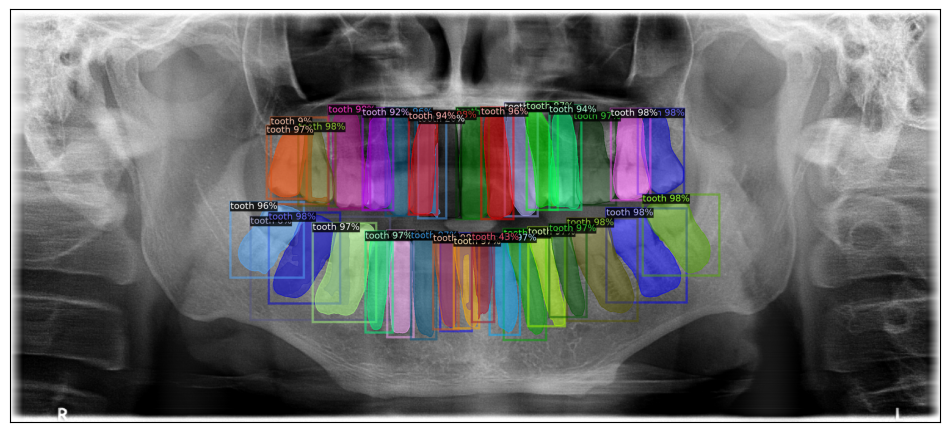


File 2 of 15: train_365.png with 34 instances.

The detection of the 34 segmentations took 1.022 seconds.



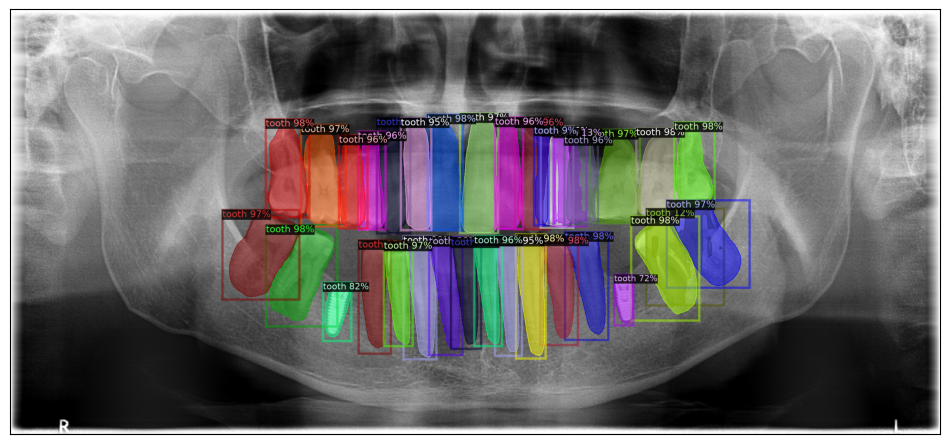


File 3 of 15: train_595.png with 38 instances.

The detection of the 38 segmentations took 1.068 seconds.



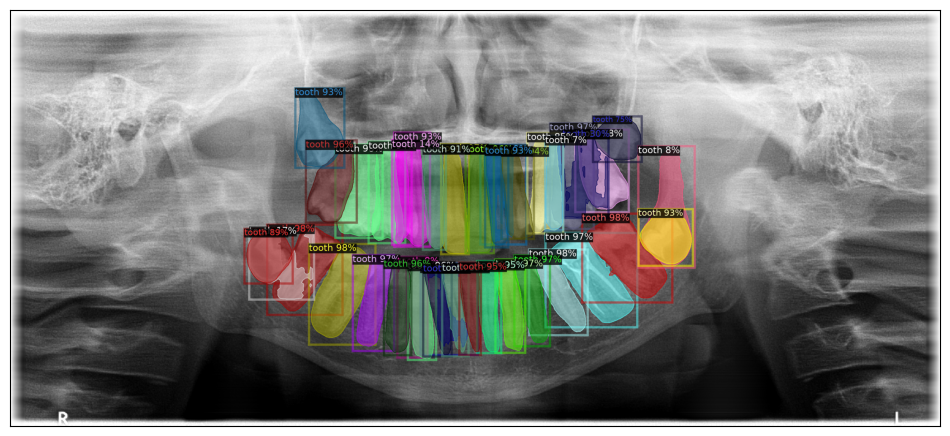


File 4 of 15: train_517.png with 46 instances.

The detection of the 46 segmentations took 1.269 seconds.



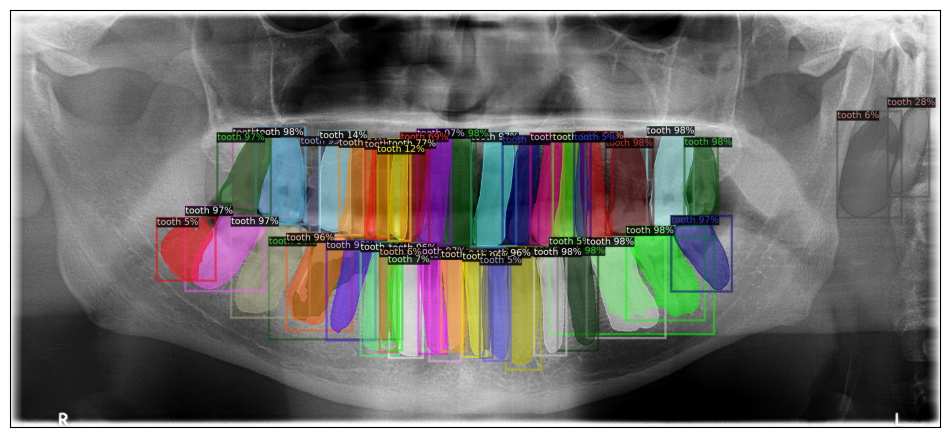


File 5 of 15: train_467.png with 38 instances.

The detection of the 38 segmentations took 1.005 seconds.



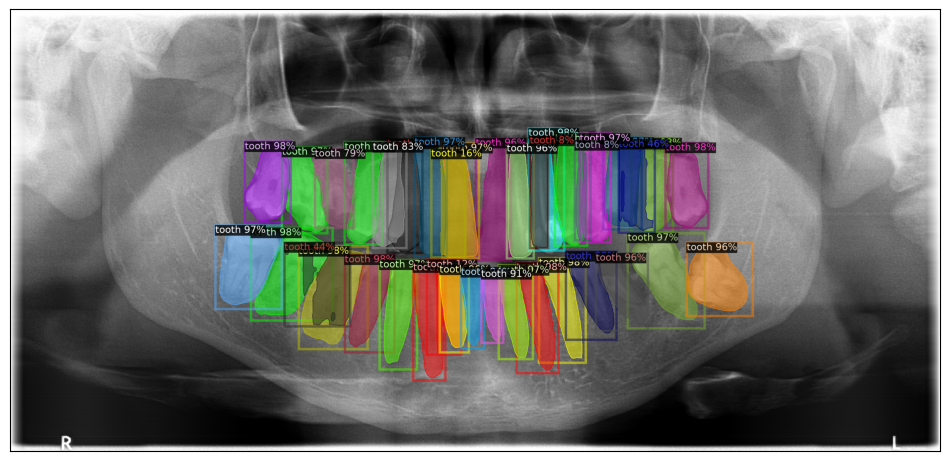

In [9]:
# Load the image
box_df_list = []
n_output_images = 15
image_number_list = files['image_number'].unique()[:n_output_images]

for i, image_number in enumerate(image_number_list[:5]):
    start_time = time.time()
    image_df = files.loc[files['image_number'] == image_number]
    image_file = image_df['file_path'].values[0]
    image_name = image_df['file_name'].values[0]
    im = ImageData().load_image(image_file)
    # Instance segmentation predictions for this image
    pred = predictor(im)
    n_instances = len(pred.get('instances'))
    # Visualizer
    metadata = MetadataCatalog.get('dentex_test')
    vis = Visualizer(img_rgb=im, metadata=metadata, scale = 1.2)
    vis = vis.draw_instance_predictions(pred.get('instances').to('cpu'))
    fig, ax = show_image(vis.get_image(), figsize=(12, 6))
    dt = (time.time() - start_time)
    print()
    print(f'File {i + 1} of {len(image_number_list)}: {image_name} with {n_instances} instances.')
    print()
    print(f'The detection of the {n_instances} segmentations took {dt:.3f} seconds.')
    print()
    
    image_name = f'{os.path.splitext(image_name)[0]}_pred.png'
    plt.savefig(os.path.join(output_dir_predictions, image_name), bbox_inches='tight')
    plt.show()